# Breast Cancer Classification — Machine Learning Project

**Author:** Lim Yin Min  
**Dataset:** Wisconsin Breast Cancer Dataset (UCI / Kaggle)  
**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn

---

## Objective

Build a machine learning classification model to predict whether a breast tumour is **malignant (cancerous)** or **benign (non-cancerous)** based on cell nucleus measurements obtained from digitised images of fine needle aspirate (FNA) biopsies.

This project demonstrates an end-to-end ML pipeline including data exploration, preprocessing, model training, evaluation, and clinical interpretation.

---

## Clinical Context

As a biotechnology graduate, I understand that in cancer diagnostics, **missing a malignant case (false negative) is far more costly than a false alarm (false positive)**. A missed diagnosis means a patient goes untreated, which can be life-threatening. A false alarm means additional tests — inconvenient but manageable.

This clinical understanding shaped my evaluation choices: I optimised for **recall** (sensitivity) alongside accuracy, not accuracy alone.

---

## Project Structure

1. Data Loading & Initial Exploration
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Model Training & Comparison
6. Model Evaluation
7. Feature Importance & Clinical Insights
8. Threshold Tuning to Improve Recall
9. ROC Curve & AUC Score

---
## 1. Data Loading & Initial Exploration

I begin by installing and importing all necessary libraries, then downloading the dataset directly from Kaggle using `kagglehub`.

Before analysis, I inspect the raw data to understand:
- How many rows (patients) and columns (features) exist
- What data types each column contains
- Whether any missing values are present


In [1]:
!pip install kagglehub

In [2]:
# Import all required libraries
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

In [4]:
# Download the Wisconsin Breast Cancer dataset from Kaggle
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Dataset path:", path)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(path + "/data.csv")
df.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Dataset path: /kaggle/input/breast-cancer-wisconsin-data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
# Inspect the dataset structure
print("Dataset shape:", df.shape)
print()
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())

Dataset shape: (569, 33)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  

**Observations from initial exploration:**
- The dataset contains **569 patients** and **33 columns**
- `Unnamed: 32` has **569 missing values** — it is completely empty and must be dropped
- The `id` column is a patient identifier with no predictive value
- All feature columns are numeric (`float64`) except `diagnosis` which is categorical (`object`)
- No other missing values exist — the dataset is otherwise clean

---
## 2. Data Cleaning

Before analysis, I remove columns that are either useless or empty.

In [7]:
# Drop the id column — not useful for prediction
df = df.drop(columns=['id'])

# Drop the empty Unnamed column if it exists
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

# Confirm the cleaned shape: should be (569, 31)
# 569 patients, 1 diagnosis column + 30 measurement features
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (569, 31)


---
## 3. Exploratory Data Analysis (EDA)

EDA is the process of understanding the data before modelling. The goal is to:
- Check class balance (are malignant and benign cases equally represented?)
- Identify which features differ most between malignant and benign tumours
- Spot correlations between features (multicollinearity)

### 3.1 Class Distribution



In [10]:
# Count malignant vs benign cases
print(df['diagnosis'].value_counts())
print()
print("Class proportions:")
print(df['diagnosis'].value_counts(normalize=True).round(3))

diagnosis
B    357
M    212
Name: count, dtype: int64

Class proportions:
diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64


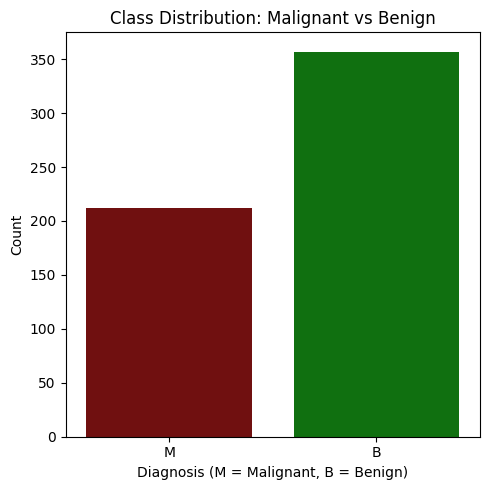

In [11]:
# Visualise class distribution
# maroon = malignant, green = benign
plt.figure(figsize=(5, 5))
sns.countplot(x='diagnosis', hue='diagnosis', data=df,
              palette={'M': 'maroon', 'B': 'green'}, legend=False)
plt.title('Class Distribution: Malignant vs Benign')
plt.xlabel('Diagnosis (M = Malignant, B = Benign)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Finding:** The dataset is moderately imbalanced — 63% benign, 37% malignant. This is not extreme, but it confirms that **accuracy alone is an insufficient metric**. Recall (sensitivity) will be evaluated to ensure the model catches as many malignant cases as possible.

### 3.2 Feature Means by Diagnosis

As a biotechnology graduate, I hypothesised that malignant tumours would show larger size measurements (radius, area, perimeter) and more irregular shapes (higher concavity) — consistent with known cancer cell biology.

In [12]:
# Compare size-based features between malignant and benign
print("Size features:")
print(df.groupby('diagnosis')[['radius_mean', 'texture_mean',
                                'perimeter_mean', 'area_mean']].mean().round(2))

print()
print("Shape features:")
print(df.groupby('diagnosis')[['concavity_mean', 'smoothness_mean',
                                'symmetry_mean', 'fractal_dimension_mean']].mean().round(4))

Size features:
           radius_mean  texture_mean  perimeter_mean  area_mean
diagnosis                                                      
B                12.15         17.91           78.08     462.79
M                17.46         21.60          115.37     978.38

Shape features:
           concavity_mean  smoothness_mean  symmetry_mean  \
diagnosis                                                   
B                  0.0461           0.0925         0.1742   
M                  0.1608           0.1029         0.1929   

           fractal_dimension_mean  
diagnosis                          
B                          0.0629  
M                          0.0627  


**Findings:**
- **Size features** (radius, area, perimeter): Malignant tumours are dramatically larger. `area_mean` is more than **double** for malignant cases (978 vs 463) — consistent with biology.
- **Concavity**: Malignant cells show much more irregular boundaries (0.161 vs 0.046) — cancer cells lose their normal structured shape.
- **Fractal dimension**: Almost identical between groups (0.063 vs 0.063) — this feature alone contributes very little to classification.

**Key insight:** Not all features are equally useful. Size and shape irregularity are strong predictors; fractal dimension is not.

### 3.3 Boxplots — Feature Distributions by Diagnosis

Boxplots show not just the average but the full spread of each feature. I plot four features chosen to illustrate the contrast between informative and non-informative features.

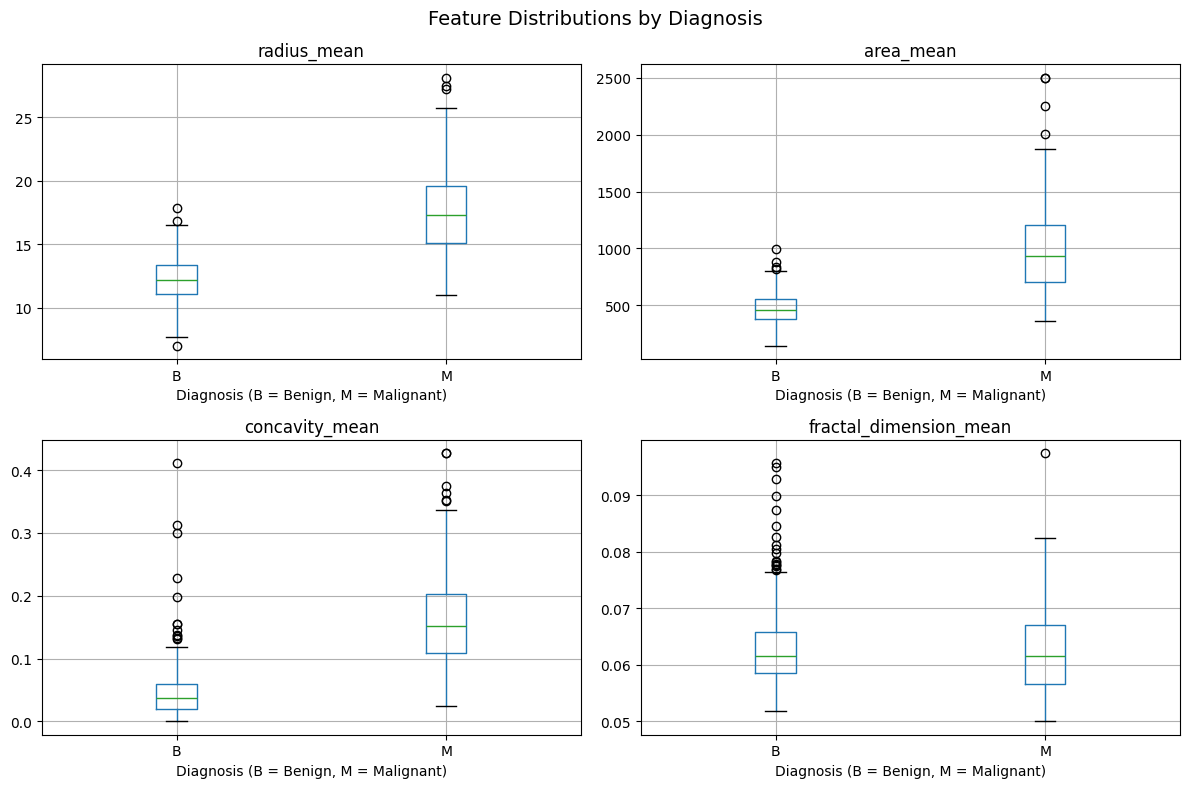

In [14]:
# Boxplots for selected features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features_to_plot = ['radius_mean', 'area_mean',
                    'concavity_mean', 'fractal_dimension_mean']

for ax, feature in zip(axes.flatten(), features_to_plot):
    df.boxplot(column=feature, by='diagnosis', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Diagnosis (B = Benign, M = Malignant)')

plt.suptitle('Feature Distributions by Diagnosis', fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

The heatmap shows how strongly every pair of features is correlated with each other.
- Values close to **1.0** (dark red): features move together — when one is large, the other is large
- Values close to **0** (white): no relationship

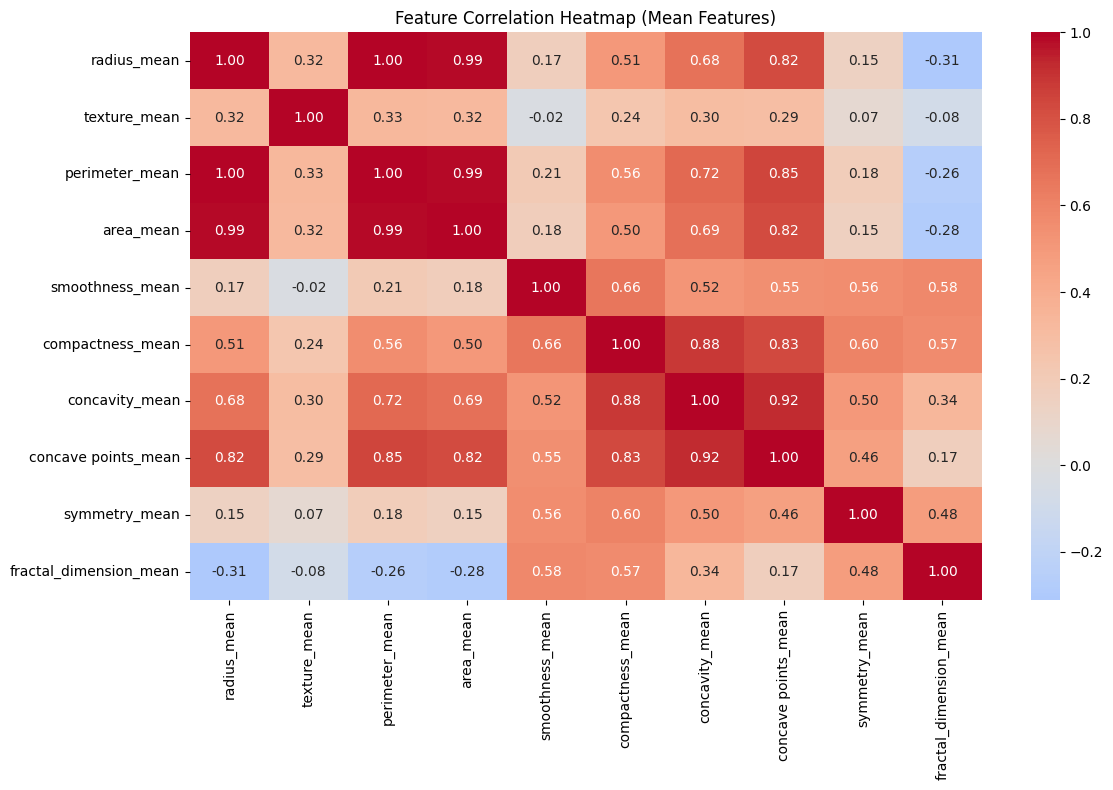

In [16]:
# Filter only mean feature columns for the heatmap
mean_cols = [c for c in df.columns if '_mean' in c]

plt.figure(figsize=(12, 8))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap (Mean Features)')
plt.tight_layout()
plt.show()

**Finding — Multicollinearity:**  
`radius_mean`, `perimeter_mean`, and `area_mean` are almost perfectly correlated (values near 1.0). This is expected — for any circular shape, if the radius increases, perimeter and area increase proportionally. These three features are essentially measuring **cell size in three different ways**, carrying largely redundant information.

I do not remove these features, as Random Forest handles multicollinearity reasonably well. In a more advanced project, PCA (Principal Component Analysis) could be used to reduce redundancy.

---
## 4. Preprocessing

Before training model, I prepare the data in three steps:
1. **Encode** the target variable — convert 'B'/'M' strings into 0/1 numbers (models only understand numbers)
2. **Split** into training and test sets — the model learns from training data, and is evaluated on unseen test data
3. **Scale** the features — bring all features to the same range so no single feature dominates due to its larger absolute values

In [18]:
# Step 1: Encode the diagnosis column
# LabelEncoder converts categorical labels to numbers alphabetically
# B (Benign) -> 0, M (Malignant) -> 1
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

print(le.classes_)
print(df[['diagnosis', 'diagnosis_encoded']].head(10))

['B' 'M']
  diagnosis  diagnosis_encoded
0         M                  1
1         M                  1
2         M                  1
3         M                  1
4         M                  1
5         M                  1
6         M                  1
7         M                  1
8         M                  1
9         M                  1


In [20]:
# Step 2: Separate features (X) and target (y)
# X = the 30 measurement columns the model uses to make predictions
# y = the correct answer (0 or 1) for each patient
X = df.drop(columns=['diagnosis', 'diagnosis_encoded'])
y = df['diagnosis_encoded']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [21]:
# Step 3: Train/test split — 80% training, 20% test
# random_state=42 ensures reproducibility — same split every time the code runs
# stratify=y ensures both sets maintain the same 63%/37% class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 455 samples
Test set:     114 samples


In [22]:
# Step 4: Feature scaling using StandardScaler
# StandardScaler transforms each feature to have mean=0 and std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Before scaling — area_mean range:")
print(f"  Min: {X_train['area_mean'].min():.2f}, Max: {X_train['area_mean'].max():.2f}")
print("After scaling — area_mean range:")
print(f"  Min: {X_train_scaled[:, 3].min():.2f}, Max: {X_train_scaled[:, 3].max():.2f}")

Before scaling — area_mean range:
  Min: 143.50, Max: 2501.00
After scaling — area_mean range:
  Min: -1.43, Max: 5.11


---
## 5. Model Training & Comparison

I train five different classification algorithms and compare them on two metrics:
- **Accuracy** — percentage of all patients correctly classified
- **Recall (Sensitivity)** — percentage of actual malignant cases correctly identified

Recall is prioritised because in cancer screening, **missing a malignant case (false negative) is far more dangerous than a false alarm (false positive)**.

In [23]:
# Define five models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}

# Train each model and record accuracy and recall
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_model = model.predict(X_test_scaled)
    acc    = accuracy_score(y_test, y_pred_model)
    recall = recall_score(y_test, y_pred_model)
    results[name] = {'accuracy': acc, 'recall': recall}
    print(f"{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Recall:   {recall:.4f}")
    print()

Logistic Regression:
  Accuracy: 0.9649
  Recall:   0.9286

Random Forest:
  Accuracy: 0.9737
  Recall:   0.9286

SVM:
  Accuracy: 0.9737
  Recall:   0.9286

KNN:
  Accuracy: 0.9561
  Recall:   0.9048

Gradient Boosting:
  Accuracy: 0.9649
  Recall:   0.9048



**Why Random Forest was selected:**
- Tied with SVM on both accuracy (97.37%) and recall (92.86%)
- Unlike SVM, Random Forest provides **feature importance scores** — revealing which measurements contribute most to predictions
- Feature importance is clinically meaningful: it tells us which cell measurements are strongest indicators of malignancy
- The fact that multiple models converge on the same recall ceiling (92.86%) suggests the data itself is the limiting factor — those remaining missed cases are genuinely ambiguous in their measurements

---
## 6. Model Evaluation — Random Forest

We evaluate the selected Random Forest model in detail using:
- Confusion matrix — shows exactly how many cases were correctly and incorrectly classified
- Classification report — precision, recall, and F1 score for each class

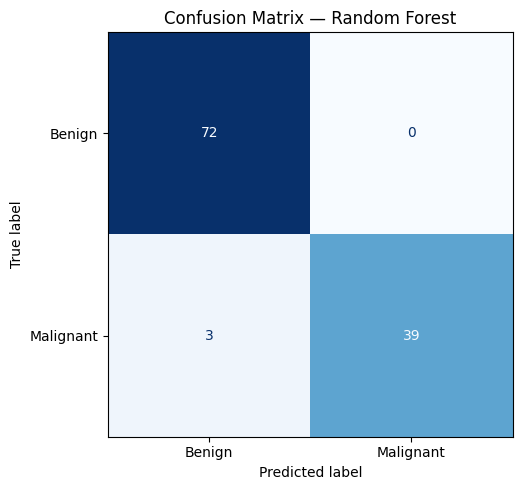

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [26]:
# Train final Random Forest model and generate predictions
rf_model = models['Random Forest']
y_pred = rf_model.predict(X_test_scaled)

# Confusion matrix
# Rows = actual diagnosis, Columns = predicted diagnosis
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

# Extract the four values from the confusion matrix
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

**Interpreting the confusion matrix:**
- **72 true negatives** — benign patients correctly sent home
- **0 false positives** — no benign patients incorrectly flagged
- **39 true positives** — malignant patients correctly identified and referred for treatment
- **3 false negatives** — 3 malignant patients were missed

**Recall for Malignant = 39 / (39 + 3) = 92.86%** — the model catches 39 out of 42 actual cancer cases.

In a real clinical setting, those 3 missed cases represent patients who would go untreated. This motivates the threshold tuning in Section 8.

---
## 7. Feature Importance & Clinical Insights

Random Forest calculates how much each feature contributed to correct predictions across all 100 trees. This allows us to rank features by their predictive importance.

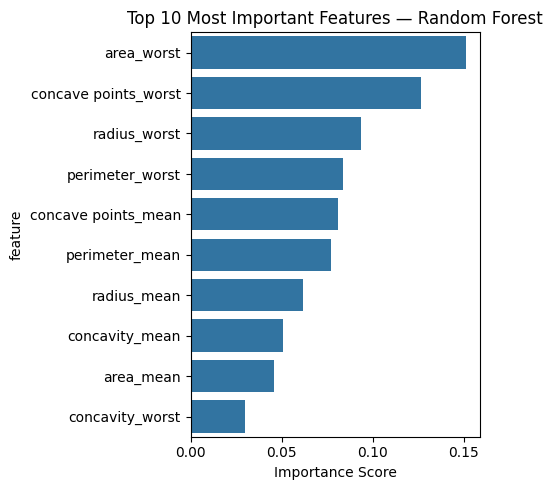

In [30]:
# Extract and visualise feature importance from Random Forest
importances   = rf_model.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(5, 5))
sns.barplot(x='importance', y='feature', data=feat_df)
plt.title('Top 10 Most Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Clinical insight:**  
The top features are `area_worst`, `concave points_worst`, and `radius_worst` — all from the `_worst` group (measurements of the most extreme cells in the sample), not the `_mean` group explored during EDA.

This makes biological sense: in a malignant tumour, not every cell looks abnormal. But the **most abnormal cells** — the worst ones — are what define malignancy. Average cell measurements (mean) are less informative than the extreme measurements (worst).

---
## 8. Threshold Tuning to Improve Recall

By default, the model predicts 'malignant' when its estimated probability exceeds **50%**. We can lower this threshold to catch more malignant cases at the cost of more false alarms.

In cancer screening, this tradeoff is clinically acceptable: a false alarm means additional tests (inconvenient but safe), while a missed malignancy can be life-threatening.

In [32]:
# Get probability scores for each patient (probability of being malignant)
# predict_proba returns [P(benign), P(malignant)] — take the second column
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Test different thresholds and observe the accuracy/recall tradeoff
print(f"{'Threshold':<12} {'Accuracy':<12} {'Recall (Malignant)'}")
print("-" * 42)
for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_t = (y_prob >= threshold).astype(int)
    acc    = accuracy_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    print(f"{threshold:<12} {acc:<12.4f} {recall:.4f}")

Threshold    Accuracy     Recall (Malignant)
------------------------------------------
0.5          0.9737       0.9286
0.4          0.9649       0.9286
0.3          0.9474       0.9286
0.2          0.9298       0.9524


**Finding:**  
Lowering the threshold to **0.2** improves recall from 92.86% to 95.24% — catching one additional malignant case — at the cost of reducing accuracy from 97.37% to 92.98%.

For a **screening tool** (first-line detection), a threshold of 0.2 or 0.3 is more appropriate — prioritising sensitivity over specificity.  
For a **confirmation tool** (used after other tests), the default 0.5 threshold is sufficient.

The optimal threshold depends on the clinical context and should be decided in consultation with medical professionals.

---
## 9. ROC Curve & AUC Score

The ROC (Receiver Operating Characteristic) curve visualises model performance across **all possible thresholds simultaneously**. It plots:
- **Y-axis:** True Positive Rate (Recall) — proportion of malignant cases caught
- **X-axis:** False Positive Rate — proportion of benign cases incorrectly flagged

**AUC (Area Under the Curve)** summarises the curve in one number:
- 1.0 = perfect model
- 0.5 = no better than random guessing
- Above 0.9 = excellent for medical applications

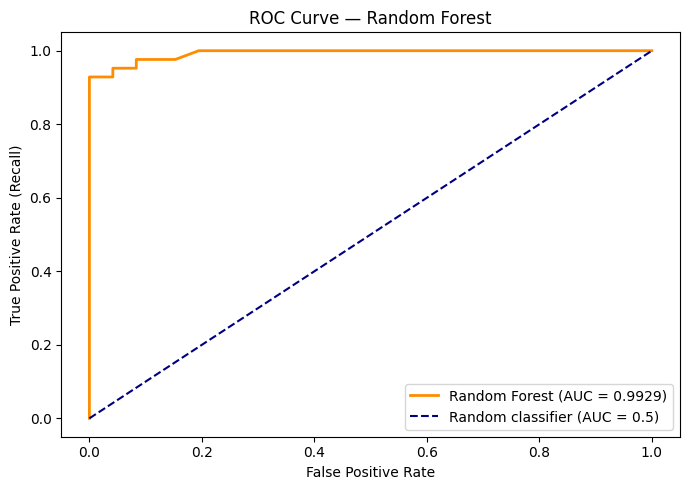

AUC Score: 0.9929


In [33]:
# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

---
## Summary of Results

| Metric | Score | Interpretation |
|--------|-------|----------------|
| Accuracy | 97.37% | 111 out of 114 test patients correctly classified |
| Recall (Malignant) | 92.86% | 39 out of 42 malignant cases correctly identified |
| AUC | 99.29% | Near-perfect separation between classes |
| False Negatives | 3 | 3 malignant patients missed at default threshold |
| False Negatives at threshold 0.2 | 2 | Reduced to 2 missed cases with threshold tuning |

---

## Key Learnings

1. **Accuracy alone is insufficient** for medical classification — a model predicting 'benign' for all patients achieves 62.7% accuracy while missing every cancer case. Recall is the more clinically meaningful metric.

2. **'Worst' features outperform 'mean' features** — the model identified extreme cell measurements (worst) as more predictive than average measurements (mean). This aligns with clinical pathology where the most atypical cells define malignancy.

3. **Multicollinearity exists** between size features (radius, perimeter, area) — they carry largely redundant information. Advanced projects could apply PCA to address this.

4. **Threshold tuning is a practical tool** — adjusting the classification threshold from 0.5 to 0.2 reduces missed malignant cases from 3 to 2, demonstrating that model deployment decisions should reflect clinical priorities.

5. **Domain knowledge adds value** — biotechnology background informed hypothesis formation during EDA and guided interpretation of model outputs in clinically meaningful terms.